<a href="https://colab.research.google.com/github/pink3y3/link_prediction-citation_network/blob/main/heuristics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Graph-Theoretic Link Prediction Baselines on the Cora Dataset

This noteboook implements and evaluates classical graph-theoretic approaches for link prediction on the Cora citation network.  
Objective - Predict if a link exists between two papers using only graph structure.

In [ ]:
!pip install torch_geometric -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import random

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from sklearn.metrics import roc_auc_score, average_precision_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.6 MB/s eta 0:00:00


In [ ]:
#load dataset
dataset=Planetoid(root='/tmp/Cora', name='Cora')
data=dataset[0]
#dataset has only one graph, so select that one graph

G=to_networkx(data, to_undirected=True)
#convert it into an undirected graph

print(f"Nodes (papers): {G.number_of_nodes()}")
print(f"Edges (citations): {G.number_of_edges()}")

Processing...


Nodes (papers): 2708
Edges (citations): 5278


Done!


Negative edges are also generated. These are pairs of nodes that are not connected in the graph. They are necessary because the model must learn the difference between connected and unconnected node pairs.

The train-test split prevents data leakage, ensures a fair evaluation, and measures how effectively the model can predict unseen connections in the network.

In [ ]:
#get all edges
all_edges=list(G.edges())

#shuffle randomly
random.seed(42)   #Every time the code runs, the edges will be shuffled in the same order
random.shuffle(all_edges)

#split 80/10/10 (training, validation(like a mock exam) and testing set(final exam))
n=len(all_edges)
train_size=int(0.8*n) #80% of randomly shuffled all_edges
val_size=int(0.1*n)

train_edges=all_edges[:train_size]  #select 0 to train_size
val_edges=all_edges[train_size:train_size+val_size]
test_edges=all_edges[train_size+val_size:] # from val_size to the end

print(f"Total edges: {n}")
print(f"Train edges: {len(train_edges)}")
print(f"Validation edges: {len(val_edges)}")
print(f"Test edges: {len(test_edges)}")

#build training graph
#remove test and val edges so model can't cheat

G_train=G.copy()
G_train.remove_edges_from(test_edges)
G_train.remove_edges_from(val_edges)

print(f"\nTraining graph: {G_train.number_of_edges()} edges")


Total edges: 5278
Train edges: 4222
Validation edges: 527
Test edges: 529

Training graph: 4222 edges
Test edges hidden — ready for prediction


Validation and test edges are hidden positive samples, not negative samples. Negative samples are separate node pairs that never had an edge in the first place.

In [ ]:
def generate_negatives(G, n_samples, seed=42):
  # G-graph(cora cn), n_samples-how many negative samples we want, seed=42-ensures reproducible random choices
  random.seed(seed)
  nodes=list(G.nodes()) # nodes conatins all 2708 paper IDs
  negatives=set() #create empty set (automatically prevents duplicates)

  while len(negatives)<n_samples:
    u=random.choice(nodes) #randomly select first node
    v=random.choice(nodes) #randomly select second node
    if u!=v and (u,v) not in G.edges() and (v,u) not in G.edges():
      negatives.add((u,v))
  return list(negatives)

test_neg=generate_negatives(G,len(test_edges))

print(f"Number of positive samples: {len(test_edges)}") #for test edges
print(f"Number of negative samples: {len(test_neg)}")   #for test edges

#doesn't have to be equal - but it makes the dataset balanced


Number of positive samples: 529
Number of negative samples: 529


In [ ]:
#Testing heuristics

def common_neighbors(G,u,v):
  u_neighbors=set(G.neighbors(u))
  v_neighbors=set(G.neighbors(v))
  """
  count how many papers u and v share
  more common papers= more likely connected
  """
  return len(u_neighbors.intersection(v_neighbors))


def jaccard_coefficient(G,u,v):
  u_neighbors=set(G.neighbors(u))
  v_neighbors=set(G.neighbors(v))

  intersection=len(u_neighbors.intersection(v_neighbors))
  union=len(u_neighbors.union(v_neighbors))
  """
  proportion of shared friends among many friends
  normalises for node degree
  """

  if union==0:
    return 0.0

  return intersection/union

def preferential_attachment(G,u,v):
  """
  popular nodes attract more connections
  product of degree= link likelihood
  no common neighbors needed
  """
  return G.degree(u) * G.degree(v)

def adamic_adar(G,u,v):
  u_neighbors=set(G.neighbors(u))
  v_neighbors=set(G.neighbors(v))
  common = u_neighbors & v_neighbors

  """
  two nodes are more likely to be connected
  if they share rare or uncommon neighbors
  """
  score=0

  for w in common:
      degree_w=G.degree(w)
      if degree_w>1:
        score+=1/np.log(degree_w)

  return score

u=list(G.nodes())[0]
v=list(G.nodes())[10]

print(f"Testing on nodes {u} and {v}:")
print(f"  Common Neighbors:        {common_neighbors(G_train, u, v)}")
print(f"  Jaccard:                 {jaccard_coefficient(G_train, u, v):.4f}")
print(f"  Adamic-Adar:             {adamic_adar(G_train, u, v):.4f}")
print(f"  Preferential Attachment: {preferential_attachment(G_train, u, v)}")



Testing on nodes 0 and 10:
  Common Neighbors:        0
  Jaccard:                 0.0000
  Adamic-Adar:             0.0000
  Preferential Attachment: 3


Inference:

CN: node 0 and node 10 share no neighbors

Jaccard: node 0 and node 10 share no neighbors

Adamic-Adar: no rare common neighbors exist either

Preferential Attachment : very small score

overall : there is very little evidence that nodes 0 and node 10 should be connected

In [ ]:
# Score every pair using each heuristic
# Positive pairs (real edges) + negative pairs (fake edges)

cn_scores  = []
j_scores   = []
aa_scores  = []
pa_scores  = []
labels     = []

print("Scoring positive pairs (real edges)...")
for u, v in test_edges:
    cn_scores.append(common_neighbors(G_train, u, v))
    j_scores.append(jaccard_coefficient(G_train, u, v))
    aa_scores.append(adamic_adar(G_train, u, v))
    pa_scores.append(preferential_attachment(G_train, u, v))
    labels.append(1)  # real edge = label 1

print("Scoring negative pairs (fake edges)...")
for u, v in test_neg:
    cn_scores.append(common_neighbors(G_train, u, v))
    j_scores.append(jaccard_coefficient(G_train, u, v))
    aa_scores.append(adamic_adar(G_train, u, v))
    pa_scores.append(preferential_attachment(G_train, u, v))
    labels.append(0)  # fake edge = label 0

print(f"\nTotal pairs scored: {len(labels)}")
print(f"Positive (real):    {sum(labels)}")
print(f"Negative (fake):    {len(labels) - sum(labels)}")

"""
For each test pair (u, v):
→ Run all 4 heuristics
→ Store the score
→ Store the true label (1=real, 0=fake)

Later:
→ Compare scores to true labels
→ Higher score should → label 1
→ Lower score should  → label 0
→ AUC measures how well this works
"""

Scoring positive pairs (real edges)...
Scoring negative pairs (fake edges)...

Total pairs scored: 1058
Positive (real):    529
Negative (fake):    529


'\nFor each test pair (u, v):\n→ Run all 4 heuristics\n→ Store the score\n→ Store the true label (1=real, 0=fake)\n\nLater:\n→ Compare scores to true labels\n→ Higher score should → label 1\n→ Lower score should  → label 0\n→ AUC measures how well this works\n'

In [ ]:
#evaluation code
# AUC = Area Under ROC Curve
# 0.5 = random guessing
# 1.0 = perfect prediction

#dictionary of results - stores key -> value
results = {
    'Common Neighbors':        roc_auc_score(labels, cn_scores),
    'Jaccard':                 roc_auc_score(labels, j_scores),
    'Adamic-Adar':             roc_auc_score(labels, aa_scores),
    'Preferential Attachment': roc_auc_score(labels, pa_scores),
}

print("======= HEURISTIC RESULTS =======")
print(f"{'Method':<25} {'AUC':>8}") #string formatting :<25 means left align 25 spaces
print("-" * 35)

for name, auc in sorted(results.items(), #gives the dictionary items
                         key=lambda x: x[1], #sort according to the second element, like ('jaccard',0.6808) it sorts by 0.6808
                         reverse=True): #highest auc(the 0.6808 thing we sorted) first
    bar = '█' * int(auc * 30)
    print(f"{name:<25} {auc:.4f}  {bar}") #formatting

print()
best  = max(results, key=results.get)
worst = min(results, key=results.get)
print(f"Best:  {best}")
print(f"Worst: {worst}")

======= HEURISTIC RESULTS =======
Method                         AUC
-----------------------------------
Adamic-Adar               0.6814  ████████████████████
Jaccard                   0.6808  ████████████████████
Common Neighbors          0.6807  ████████████████████
Preferential Attachment   0.6377  ███████████████████

Best:  Adamic-Adar
Worst: Preferential Attachment


In citation netowrk, absence of an edge does not necessarily mean a true negative.

what if the negative edge has a high score? - counted as an error(fp)

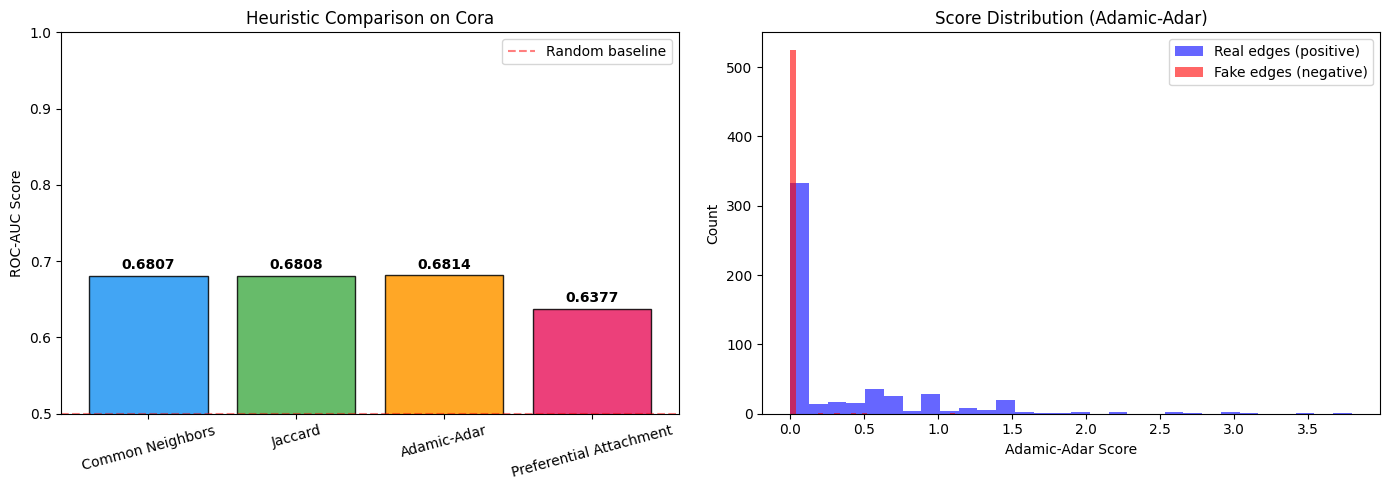

Plots saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # 1 row 2 columns
#fig=the entire figure, axes=array containng the two plots

#Plot 1: Bar Chart
names  = list(results.keys())
values = list(results.values())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

bars = axes[0].bar(names, values,
                   color=colors,
                   edgecolor='black',
                   alpha=0.85) #controls transparency

# Add value on top of each bar
for bar, val in zip(bars, values): #zip pairs things together
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, #middle of the bar
        bar.get_height() + 0.005, #add 0.005 to the height of the bar
        f'{val:.4f}', #with four decimal places
        ha='center', va='bottom', #horizontal align and vertical align
        fontweight='bold', fontsize=10
    )

axes[0].set_ylim(0.5, 1.0) #show values from 0.5 to 1 on the y axis
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_title('Heuristic Comparison on Cora')
axes[0].tick_params(axis='x', rotation=15) #tilt method names slightly
axes[0].axhline(y=0.5, color='red',
                linestyle='--', alpha=0.5,
                label='Random baseline')
axes[0].legend()

#Plot 2: Score Distribution (Histogram)
axes[1].hist(
    [s for s, l in zip(aa_scores, labels) if l == 1], #list comparehension
    bins=30, alpha=0.6, color='blue',
    label='Real edges (positive)'
)
axes[1].hist(
    [s for s, l in zip(aa_scores, labels) if l == 0],
    bins=30, alpha=0.6, color='red', #bins divide the x-axis into 30 intervals
    label='Fake edges (negative)'
)
axes[1].set_xlabel('Adamic-Adar Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Distribution (Adamic-Adar)')
axes[1].legend()

plt.tight_layout()
plt.savefig('heuristics_results.png', dpi=150)
plt.show()
print("Plots saved!")

All heuristics perform better than random guessing because AUC>0.5.
Adamic-Adar performs the best - which suggests that in citation networks, rare shared neighbors are more informative than simply counting common neighbors.
Intuitively, if two papers cite a niche paper, they're likely in the same research area.

Common neighbors and Jaccard are almost identical - which means by normalising the union of neighbors doesn't add much information for Cora

Preferential Attachment performs noticeably worse - papers don't cite another paper just because it's famous; they cite papers that are topically related (items are connected by sharing the same topic/theme)



Adamic Adar Distribution

Most negative edges have AA score = 0 - most randomly chosen non-edges share no meaningful neighbors

Positive edges have a wider distribution - real citation links tend to have hgiher Adamic-Adar scores

There is overlap between the two distributions
some positive edges have score 0 and some negative edges have higher scores
-

In [ ]:
import pandas as pd

# Save results to CSV
results_df = pd.DataFrame({
    'Method': list(results.keys()),
    'AUC':    list(results.values())
})

results_df.to_csv('heuristics_results.csv', index=False)
print("Results saved to CSV!")
print(results_df)

Results saved to CSV!
                    Method       AUC
0         Common Neighbors  0.680712
1                  Jaccard  0.680760
2              Adamic-Adar  0.681351
3  Preferential Attachment  0.637689
